# Non-new complex rules across stages — all FOVs


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 3
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

# The stage column is chosen per run, not per notebook:
#   SCORE_COLUMN="Pathological score" jupyter nbconvert --execute ...
SCORE_COLUMN = os.environ.get("SCORE_COLUMN", "Clinical score")
SCORE_TAG = "path" if SCORE_COLUMN.startswith("Patho") else "clin"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = False
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2

SCOPE = "all"    # tags every figure this notebook saves


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 213816 rules (max_items=3, kind=None).


## Short analysis functions


In [4]:
def slug(text):
    """A short file-safe name for a rule."""
    text = str(text).lower().replace(" -> ", "_").replace(",", "").replace(" ", "_")
    return "".join(ch for ch in text if ch.isalnum() or ch == "_")[:60]


def figure_name(scope, kind, organ, panel, name=None):
    """One naming rule for every figure this notebook saves."""
    parts = [scope, SCORE_TAG, kind, organ.lower(), panel]
    if name is not None:
        parts.append(slug(name))
    return "_".join(parts) + ".png"


def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        "non-new complex rules",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=False,
        min_strength=1.0,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=False))
        vis.plot_prevalence_overview(
            top, STAGES, organ=organ, params=scope_label(kind),
            save=figure_name(SCOPE, kind, organ, "overview"),
        )

        opposed = stage.opposite_direction_rules(
            prevalence, STAGES, MIN_RULE_FOVS
        )
        display(stage.opposite_table(opposed))
        vis.plot_opposite_directions(
            opposed, STAGES, organ=organ, params=scope_label(kind),
            save=figure_name(SCOPE, kind, organ, "opposite"),
        )

        chosen = stage.detail_rules(
            complex_rules, ranked_names, DETAIL_RULES, new_only=False
        )
        chosen = list(dict.fromkeys(chosen + list(ranked_names[:DETAIL_RULES])))
        for name in chosen:
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            abundance = stage.cell_abundance(
                name,
                complex_rules,
                df_cells,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=False,
                abundance=abundance,
                save=figure_name(SCOPE, kind, organ, "rule", name),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=False,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="Complex rule and strongest simpler rule",
                params=scope_label(kind),
                cell_size=11,
                save=figure_name(SCOPE, kind, organ, "fovs", name),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence,simpler prevalence
315,"Plasma, Treg -> CD4T",Control,6 / 25 (24%),14 / 25 (56%)
316,"Plasma, Treg -> CD4T",Mild,0 / 40 (0%),3 / 40 (8%)
317,"Plasma, Treg -> CD4T",Severe,0 / 32 (0%),4 / 32 (12%)
393,"Plasma -> CD4T, Epithelial",Control,5 / 25 (20%),15 / 25 (60%)
394,"Plasma -> CD4T, Epithelial",Mild,2 / 40 (5%),2 / 40 (5%)
395,"Plasma -> CD4T, Epithelial",Severe,0 / 32 (0%),3 / 32 (9%)
798,"Plasma -> CD8T, Macrophage",Control,5 / 25 (20%),13 / 25 (52%)
799,"Plasma -> CD8T, Macrophage",Mild,0 / 40 (0%),6 / 40 (15%)
800,"Plasma -> CD8T, Macrophage",Severe,0 / 32 (0%),4 / 32 (12%)
717,"SMV -> CD8T, Endothelial",Control,5 / 25 (20%),15 / 25 (60%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_colon_overview.png


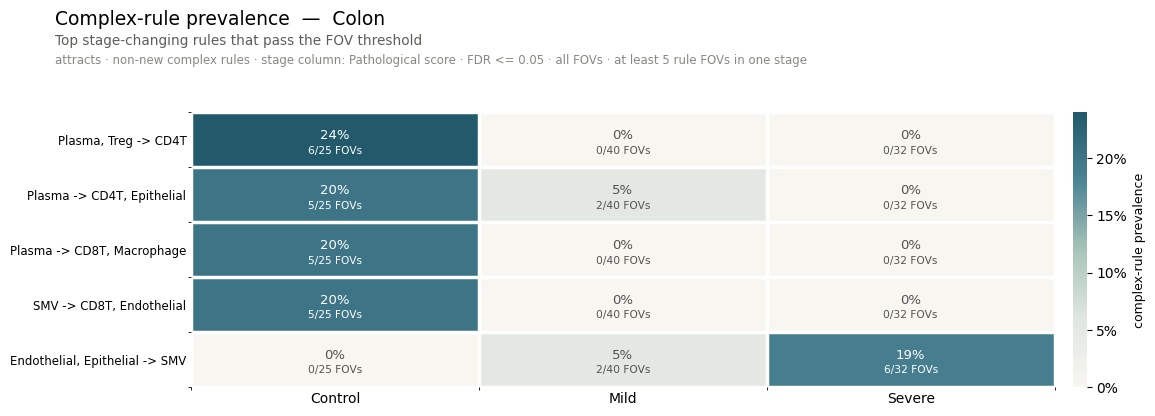

,note
0,No rule moves both ways by the required margin.


No opposite-direction rules to plot.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_colon_rule_plasma_treg_cd4t.png


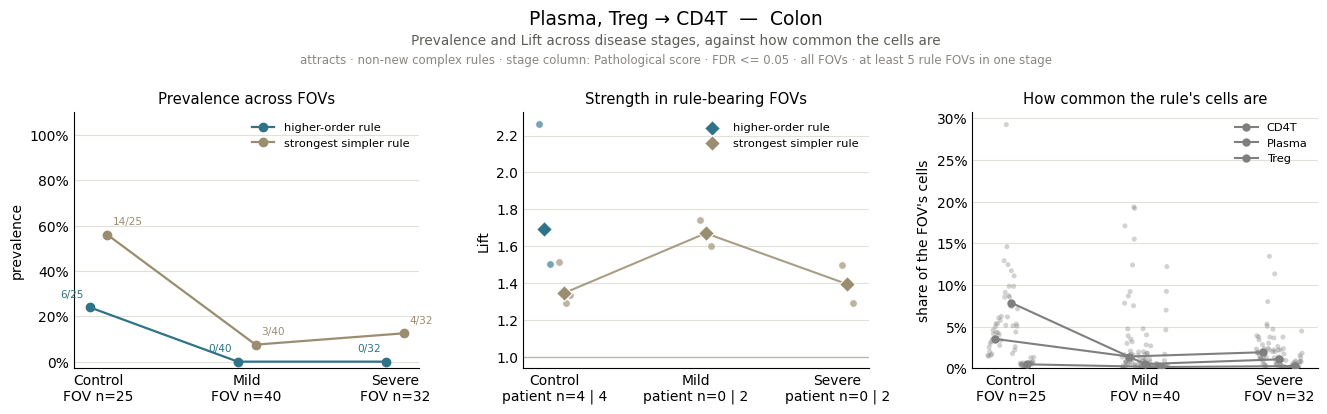

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_colon_fovs_plasma_treg_cd4t.png


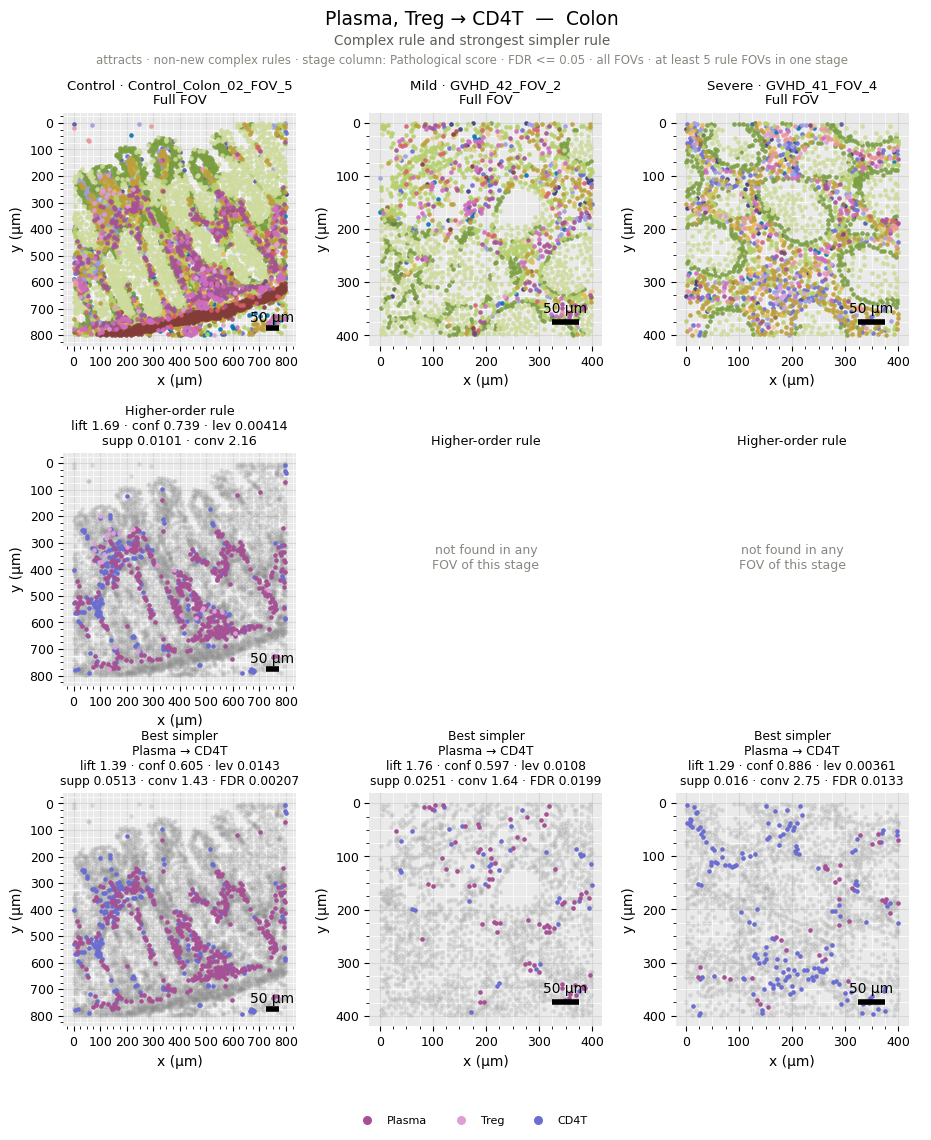

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_colon_rule_plasma_cd4t_epithelial.png


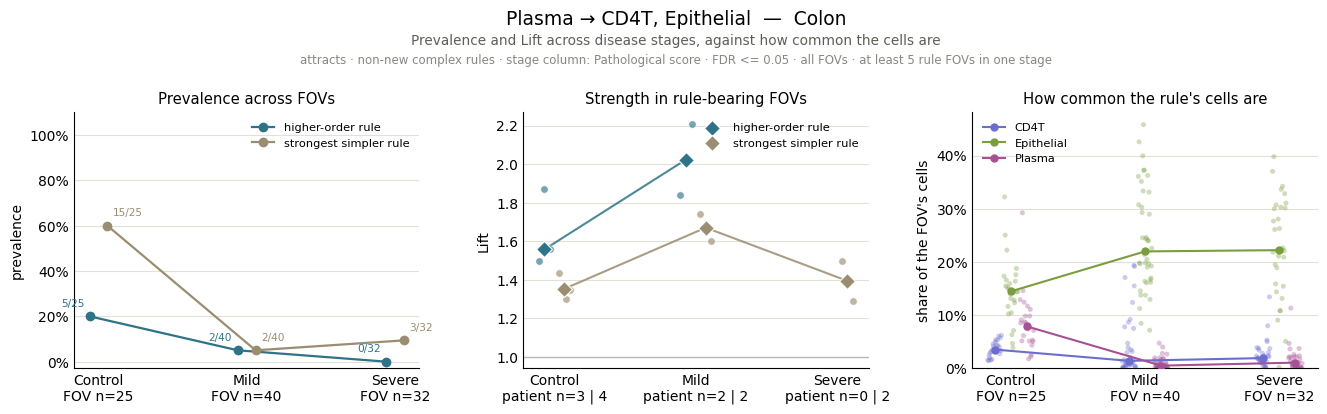

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_colon_fovs_plasma_cd4t_epithelial.png


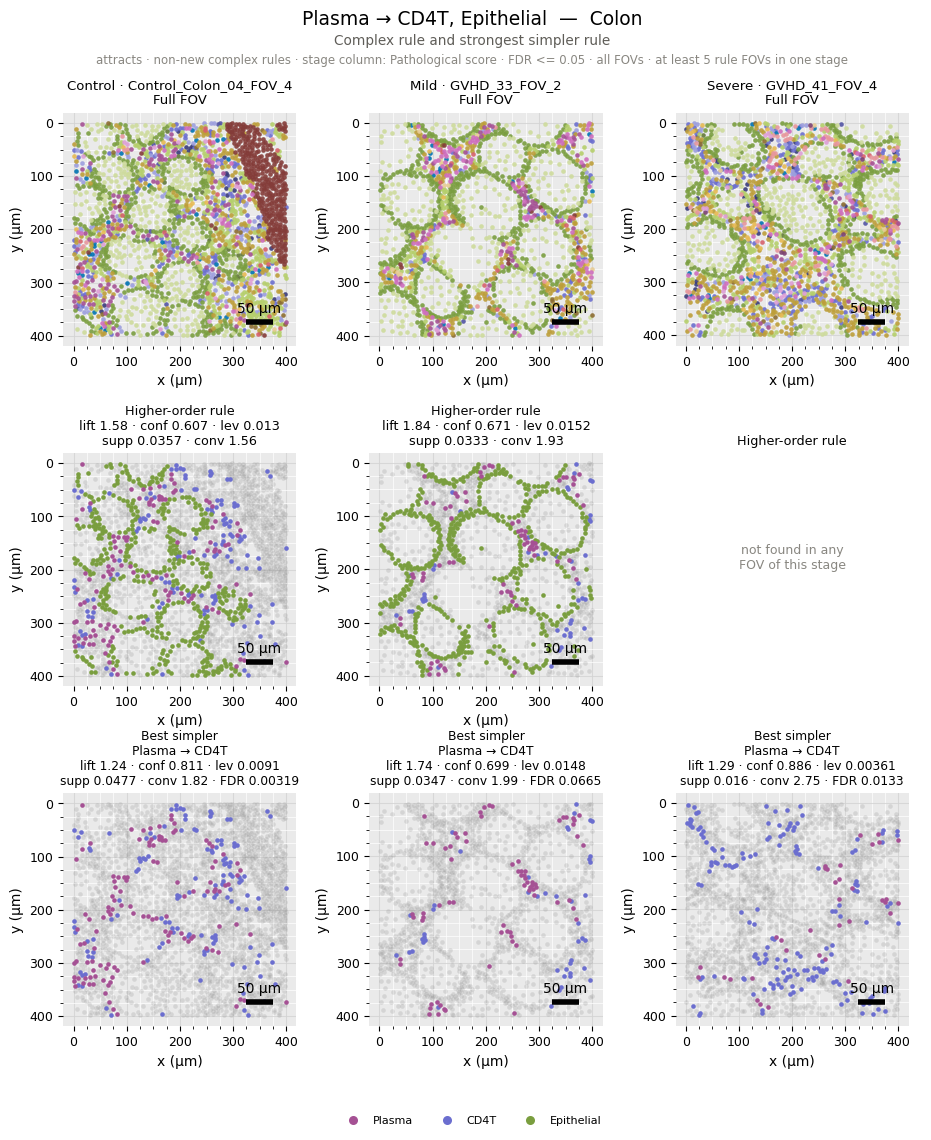

### Duodenum

,name,stage,complex prevalence,simpler prevalence
117,"Epithelial, SMV -> Endothelial",Control,5 / 31 (16%),10 / 31 (32%)
118,"Epithelial, SMV -> Endothelial",Mild,7 / 103 (7%),40 / 103 (39%)
119,"Epithelial, SMV -> Endothelial",Severe,0 / 36 (0%),15 / 36 (42%)
132,"SMV -> CD4T, Endothelial",Control,5 / 31 (16%),12 / 31 (39%)
133,"SMV -> CD4T, Endothelial",Mild,2 / 103 (2%),46 / 103 (45%)
134,"SMV -> CD4T, Endothelial",Severe,0 / 36 (0%),15 / 36 (42%)
393,"Plasma -> CD4T, Epithelial",Control,1 / 31 (3%),6 / 31 (19%)
394,"Plasma -> CD4T, Epithelial",Mild,16 / 103 (16%),19 / 103 (18%)
395,"Plasma -> CD4T, Epithelial",Severe,0 / 36 (0%),2 / 36 (6%)
12,"Plasma -> Epithelial, Macrophage",Control,3 / 31 (10%),6 / 31 (19%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_overview.png


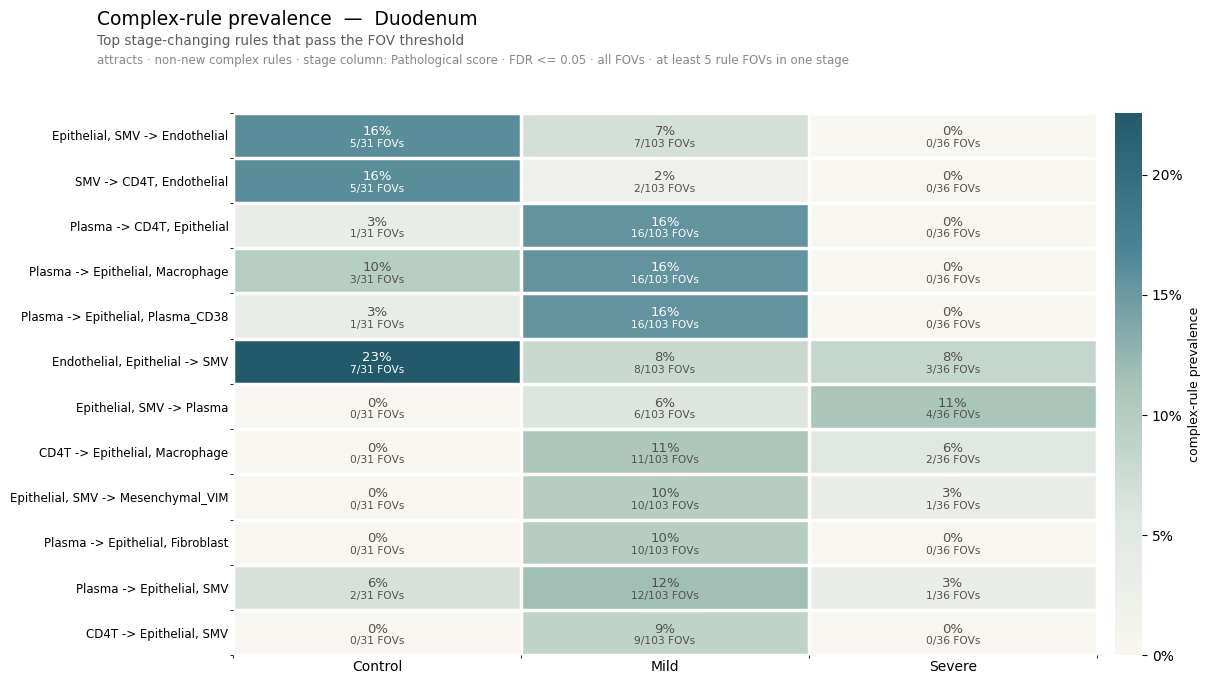

,rule,complex,simpler,FOVs
0,"Endothelial, Epithelial -> SMV",23% -> 8%,3% -> 19%,8
1,"Epithelial, SMV -> Plasma",0% -> 11%,13% -> 3%,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_opposite.png


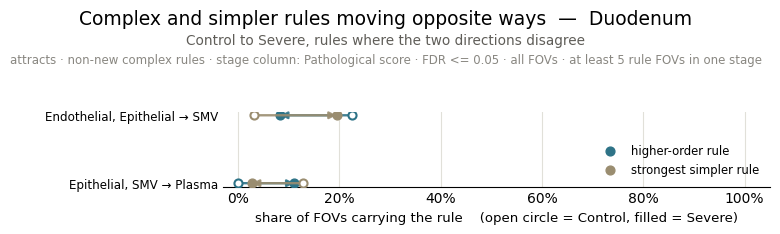

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_rule_epithelial_smv_endothelial.png


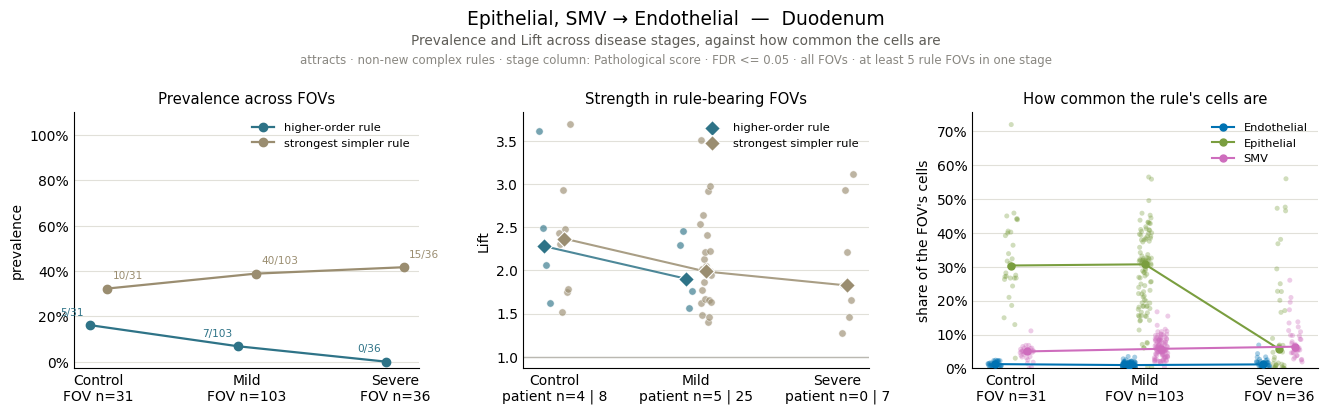

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_fovs_epithelial_smv_endothelial.png


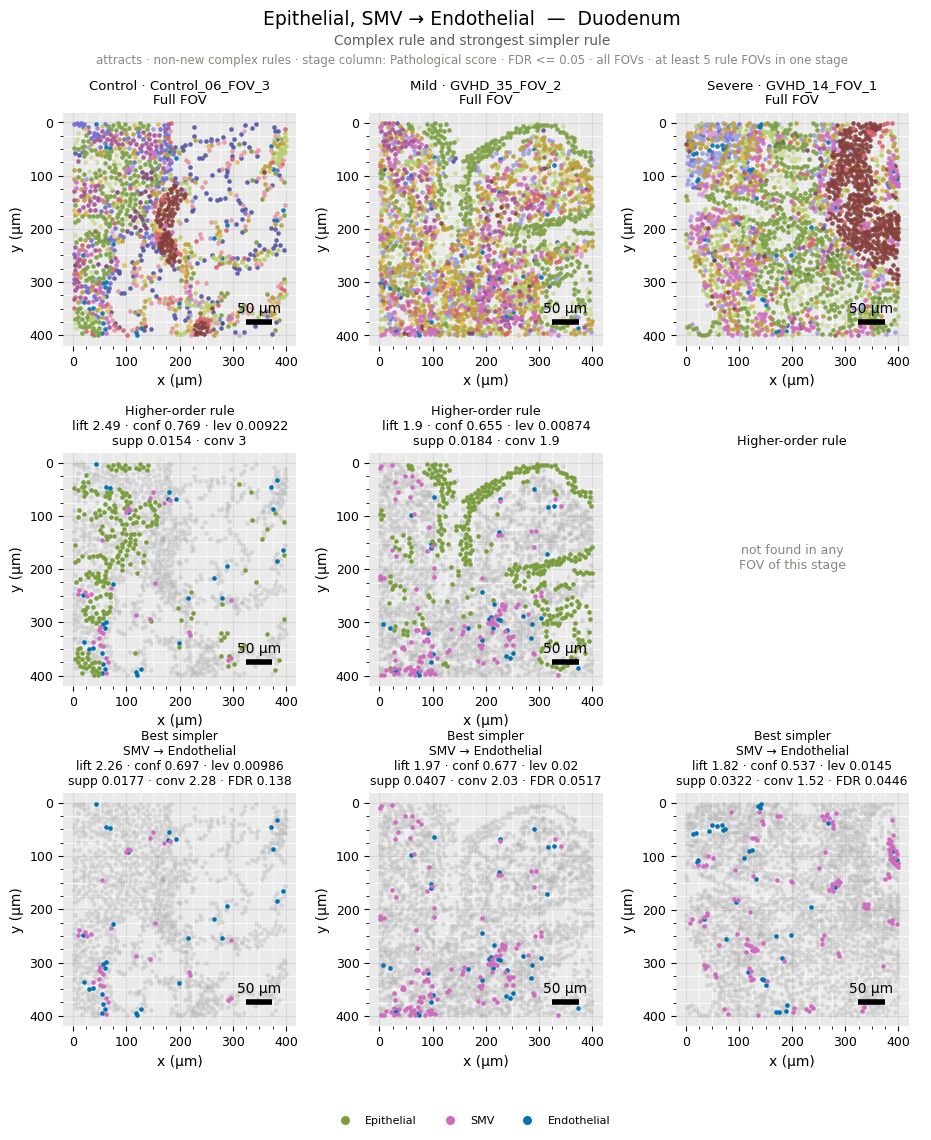

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_rule_smv_cd4t_endothelial.png


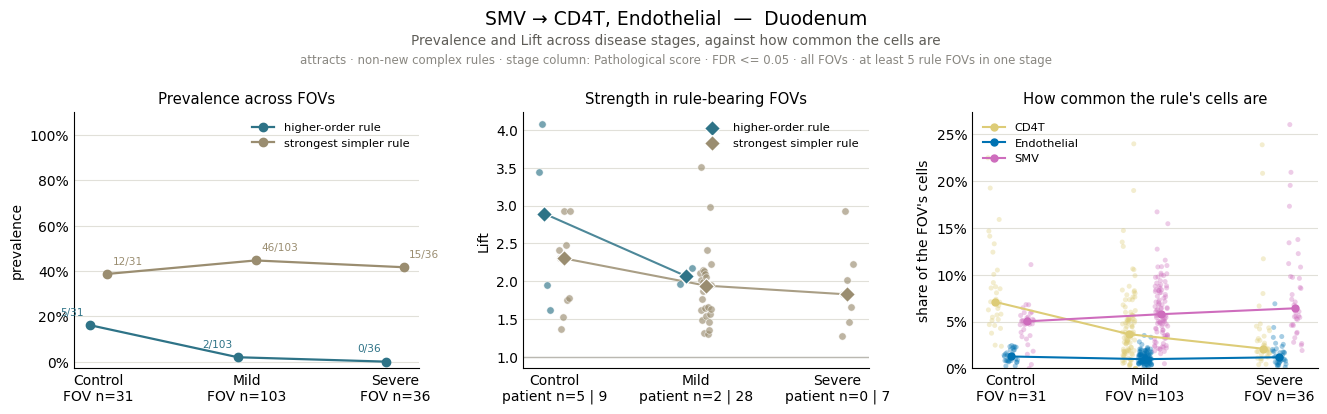

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_attracts_duodenum_fovs_smv_cd4t_endothelial.png


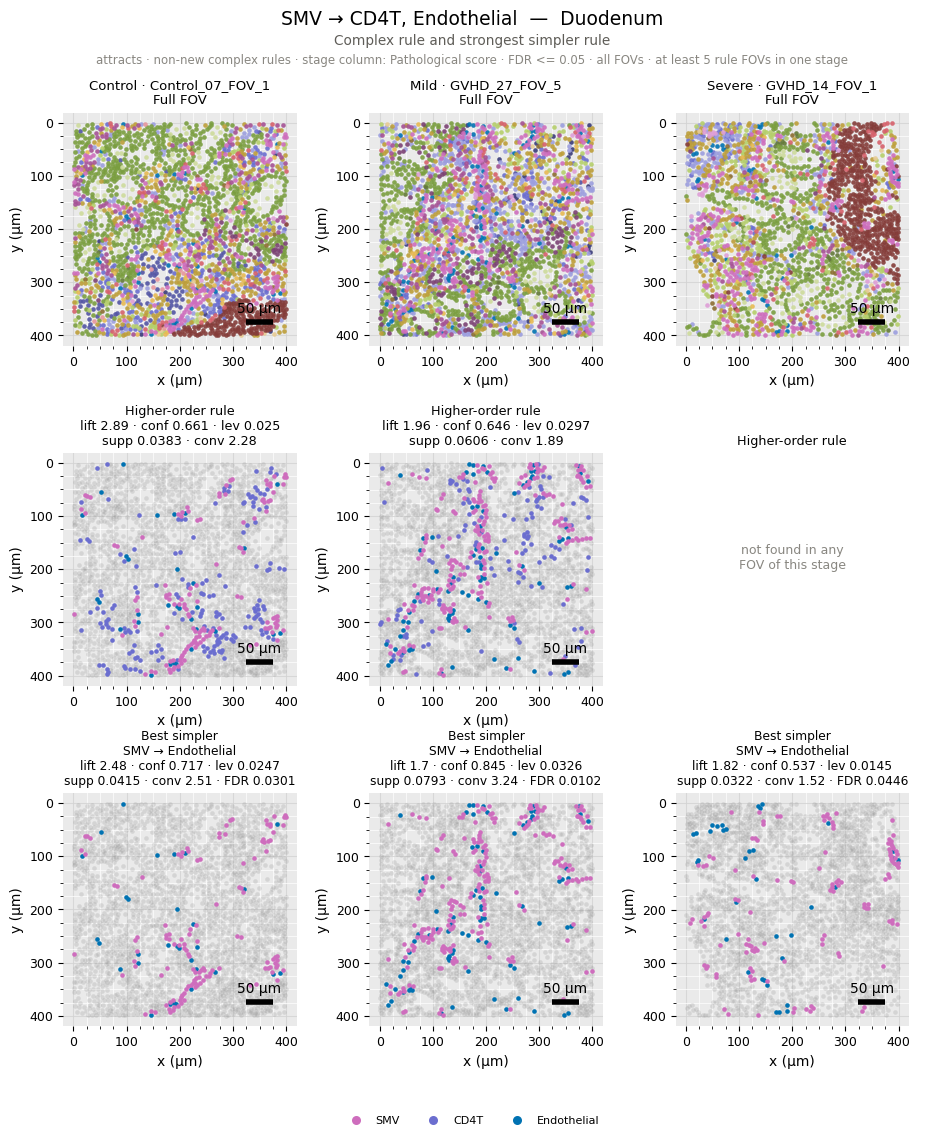

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,complex prevalence,simpler prevalence
234,"Goblet -> CD8T, Plasma",Control,23 / 25 (92%),25 / 25 (100%)
235,"Goblet -> CD8T, Plasma",Mild,5 / 40 (12%),34 / 40 (85%)
236,"Goblet -> CD8T, Plasma",Severe,4 / 32 (12%),25 / 32 (78%)
330,"Goblet -> CD4T, Plasma",Control,22 / 25 (88%),25 / 25 (100%)
331,"Goblet -> CD4T, Plasma",Mild,7 / 40 (18%),31 / 40 (78%)
332,"Goblet -> CD4T, Plasma",Severe,3 / 32 (9%),18 / 32 (56%)
132,"Goblet -> CD4T, CD8T",Control,24 / 25 (96%),25 / 25 (100%)
133,"Goblet -> CD4T, CD8T",Mild,15 / 40 (38%),34 / 40 (85%)
134,"Goblet -> CD4T, CD8T",Severe,9 / 32 (28%),25 / 32 (78%)
294,"Goblet -> Fibroblast, Plasma",Control,21 / 25 (84%),25 / 25 (100%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_overview.png


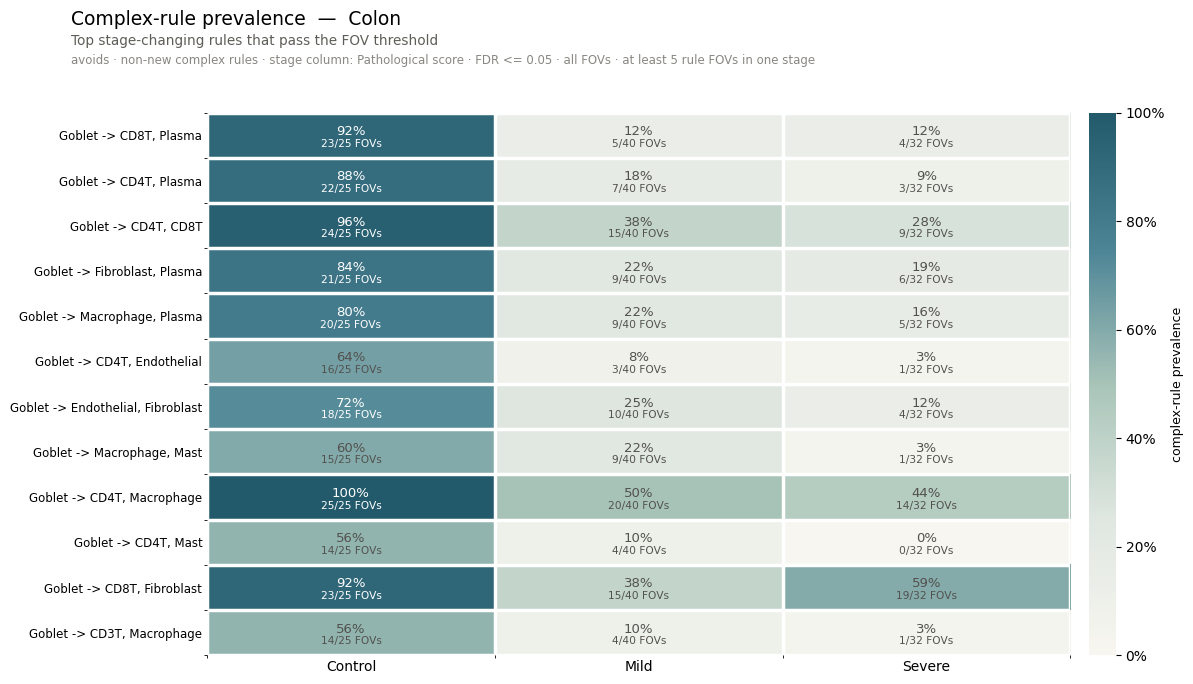

,rule,complex,simpler,FOVs
0,"Fibroblast, ImmuneOther -> Goblet",24% -> 3%,40% -> 59%,6
1,"Goblet -> Neutrophil, SMV",0% -> 16%,92% -> 69%,5
2,"Goblet -> CD8T, Neutrophil",0% -> 16%,96% -> 78%,5
3,"CD4T, Fibroblast -> Goblet",12% -> 28%,72% -> 59%,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_opposite.png


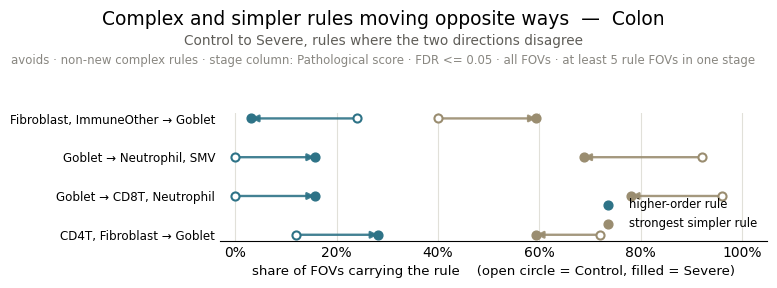

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_rule_goblet_cd8t_plasma.png


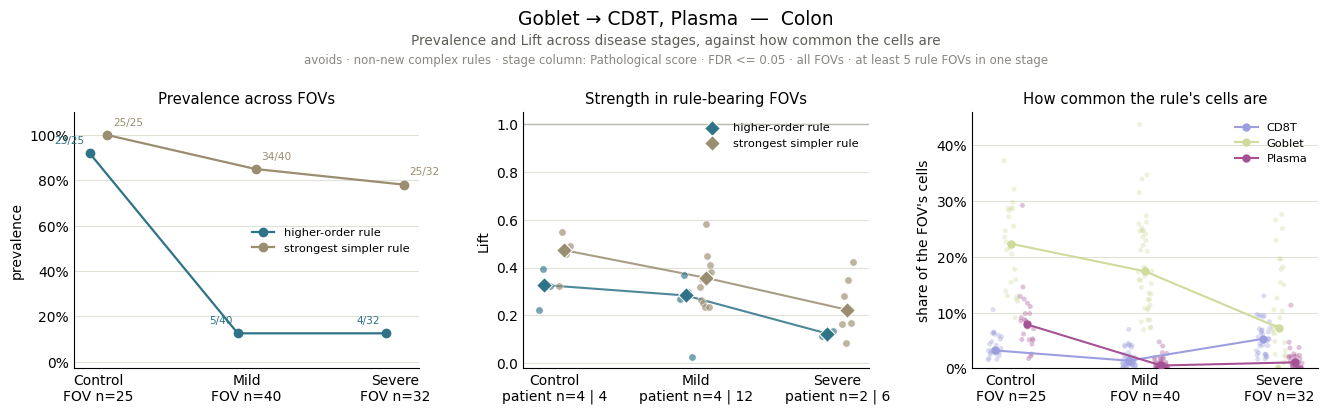

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_fovs_goblet_cd8t_plasma.png


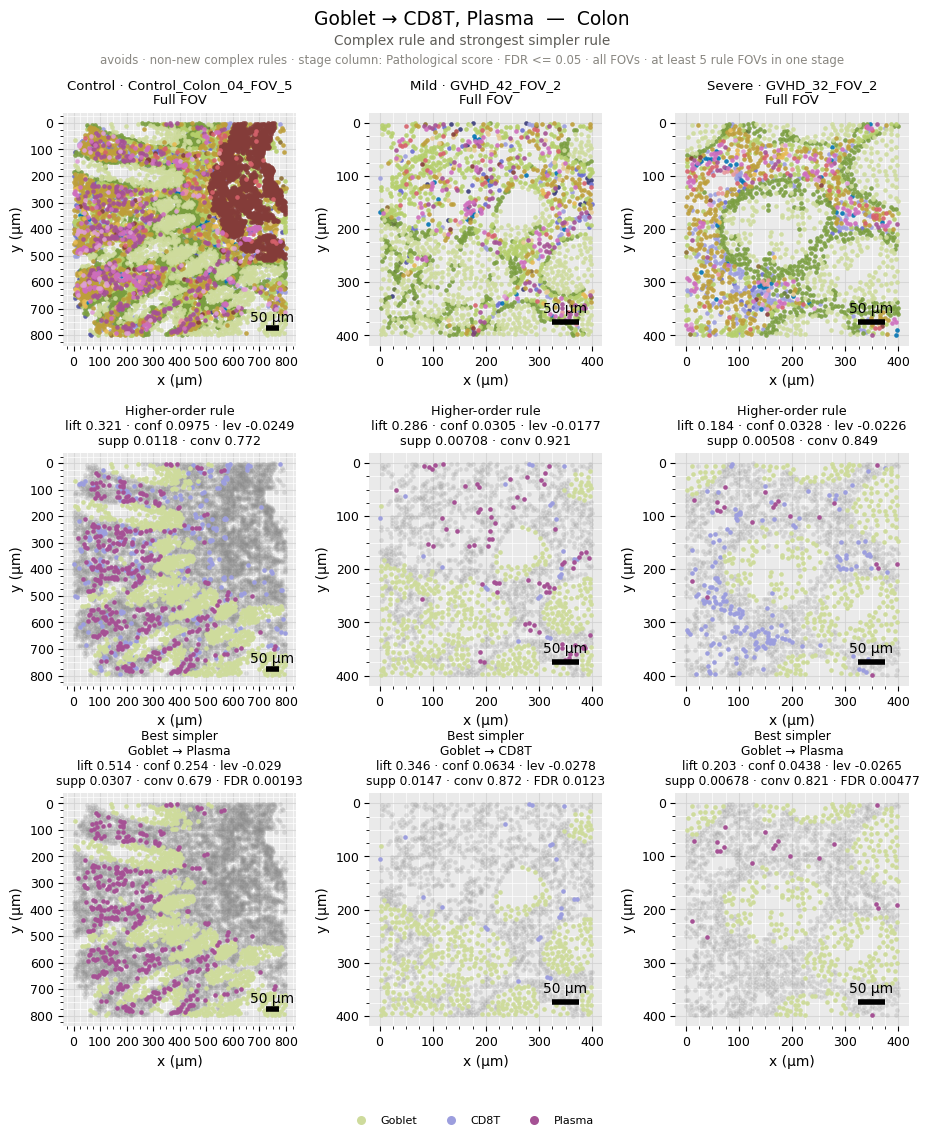

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_rule_goblet_cd4t_plasma.png


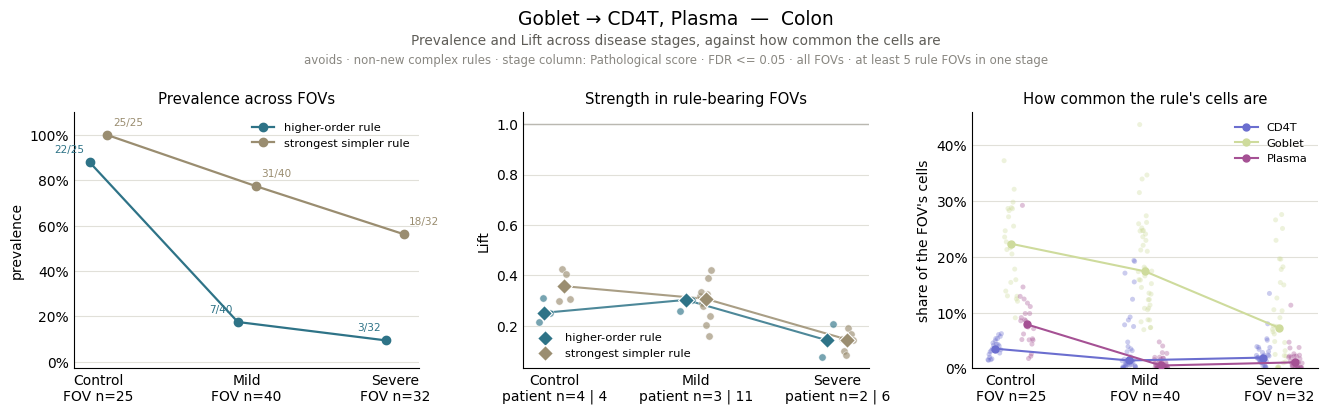

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_colon_fovs_goblet_cd4t_plasma.png


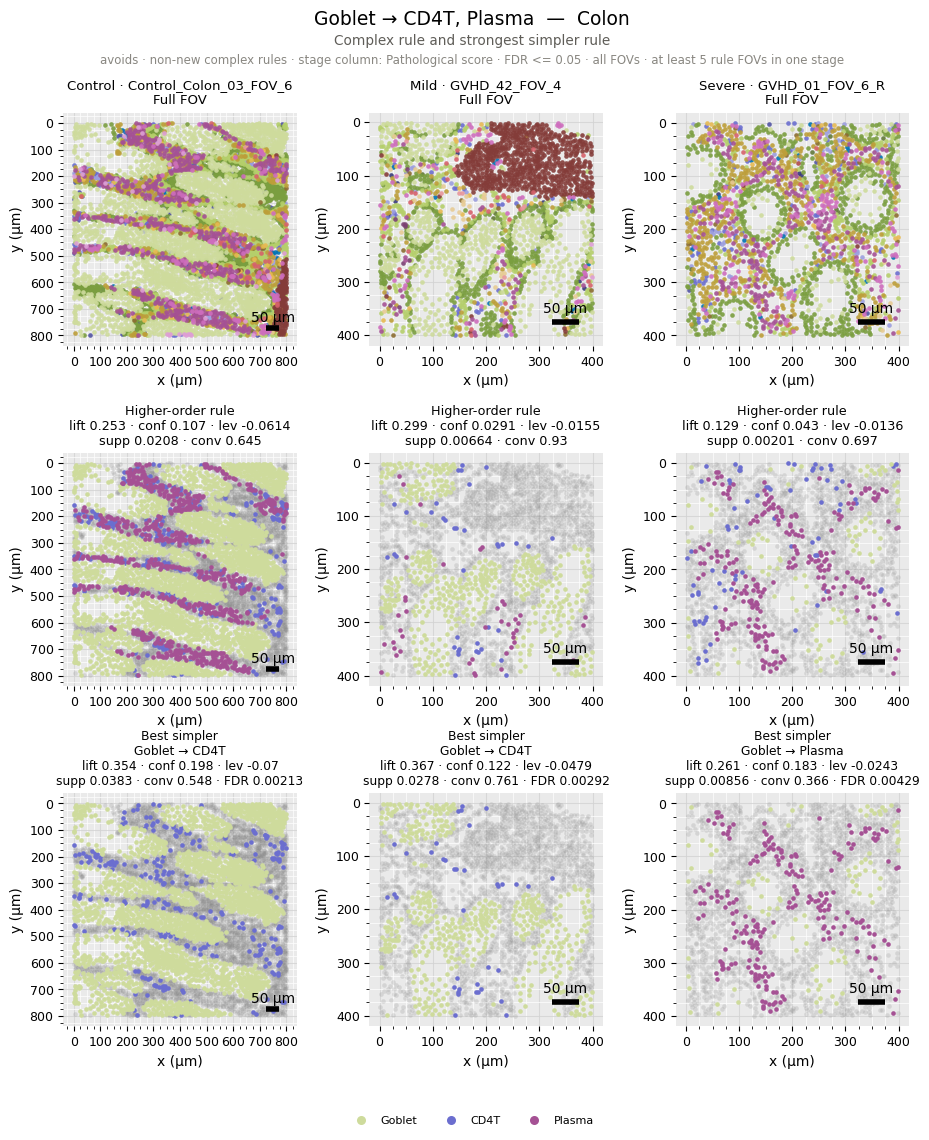

### Duodenum

,name,stage,complex prevalence,simpler prevalence
21,"Goblet -> CD4T, Macrophage",Control,20 / 31 (65%),29 / 31 (94%)
22,"Goblet -> CD4T, Macrophage",Mild,52 / 103 (50%),86 / 103 (83%)
23,"Goblet -> CD4T, Macrophage",Severe,4 / 36 (11%),12 / 36 (33%)
225,"Goblet -> Fibroblast, Macrophage",Control,22 / 31 (71%),29 / 31 (94%)
226,"Goblet -> Fibroblast, Macrophage",Mild,73 / 103 (71%),88 / 103 (85%)
227,"Goblet -> Fibroblast, Macrophage",Severe,8 / 36 (22%),12 / 36 (33%)
1059,"Goblet -> Fibroblast, Neuron",Control,1 / 31 (3%),26 / 31 (84%)
1060,"Goblet -> Fibroblast, Neuron",Mild,47 / 103 (46%),84 / 103 (82%)
1061,"Goblet -> Fibroblast, Neuron",Severe,4 / 36 (11%),11 / 36 (31%)
141,"Goblet -> Fibroblast, SMV",Control,5 / 31 (16%),27 / 31 (87%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_duodenum_overview.png


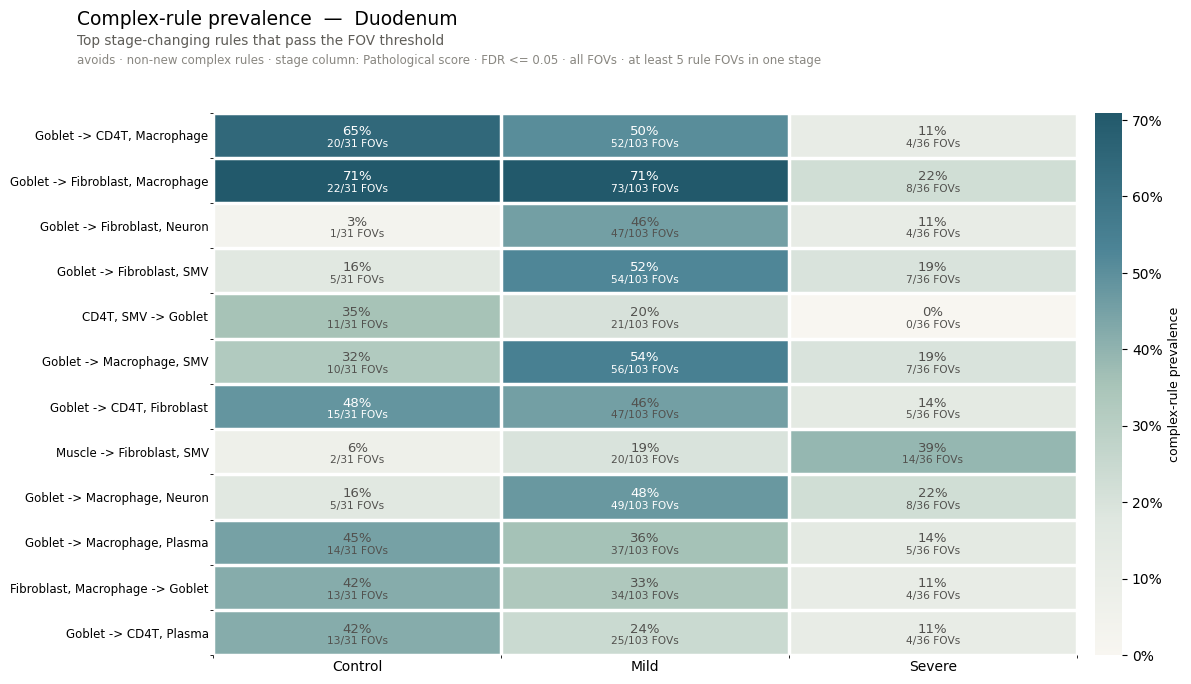

,note
0,No rule moves both ways by the required margin.


No opposite-direction rules to plot.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_duodenum_rule_goblet_cd4t_macrophage.png


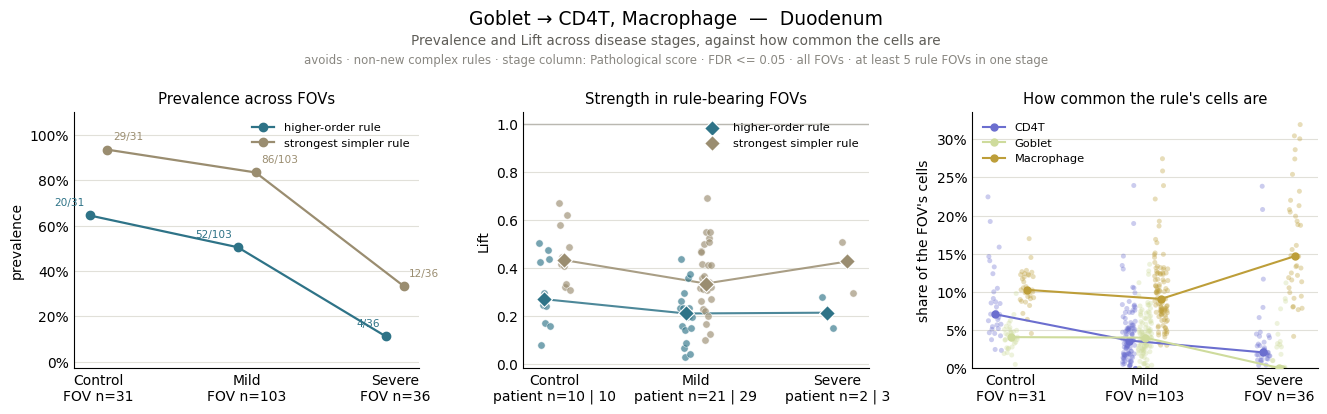

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_duodenum_fovs_goblet_cd4t_macrophage.png


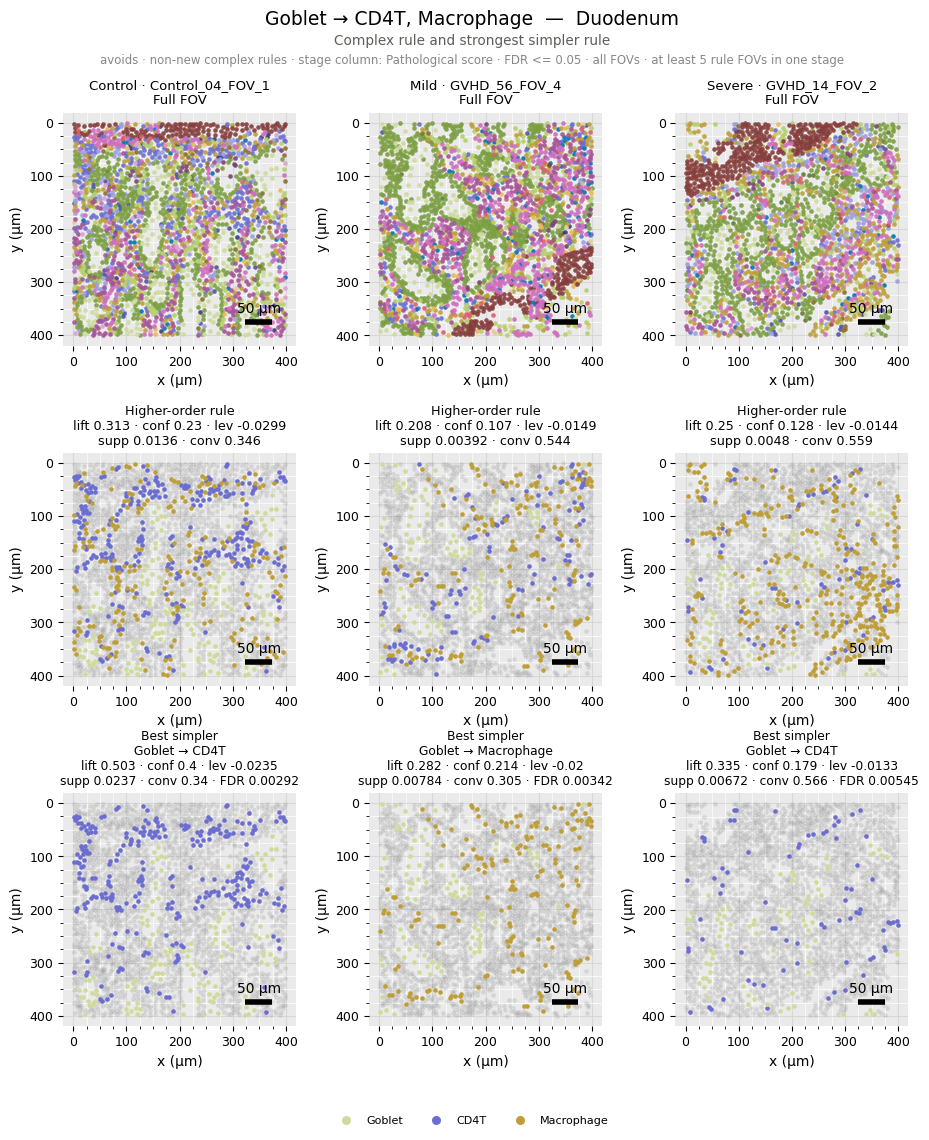

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_duodenum_rule_goblet_fibroblast_macrophage.png


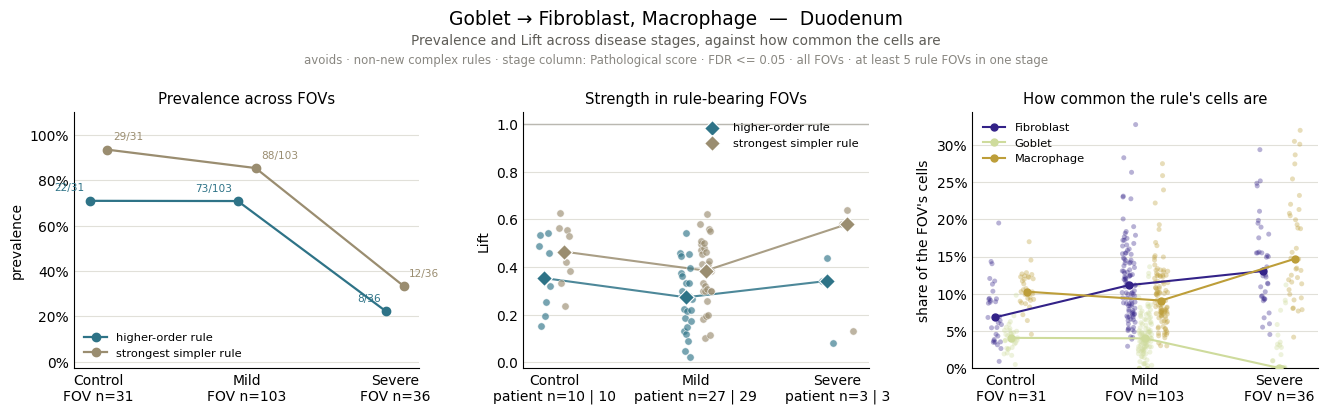

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\all_path_avoids_duodenum_fovs_goblet_fibroblast_macrophage.png


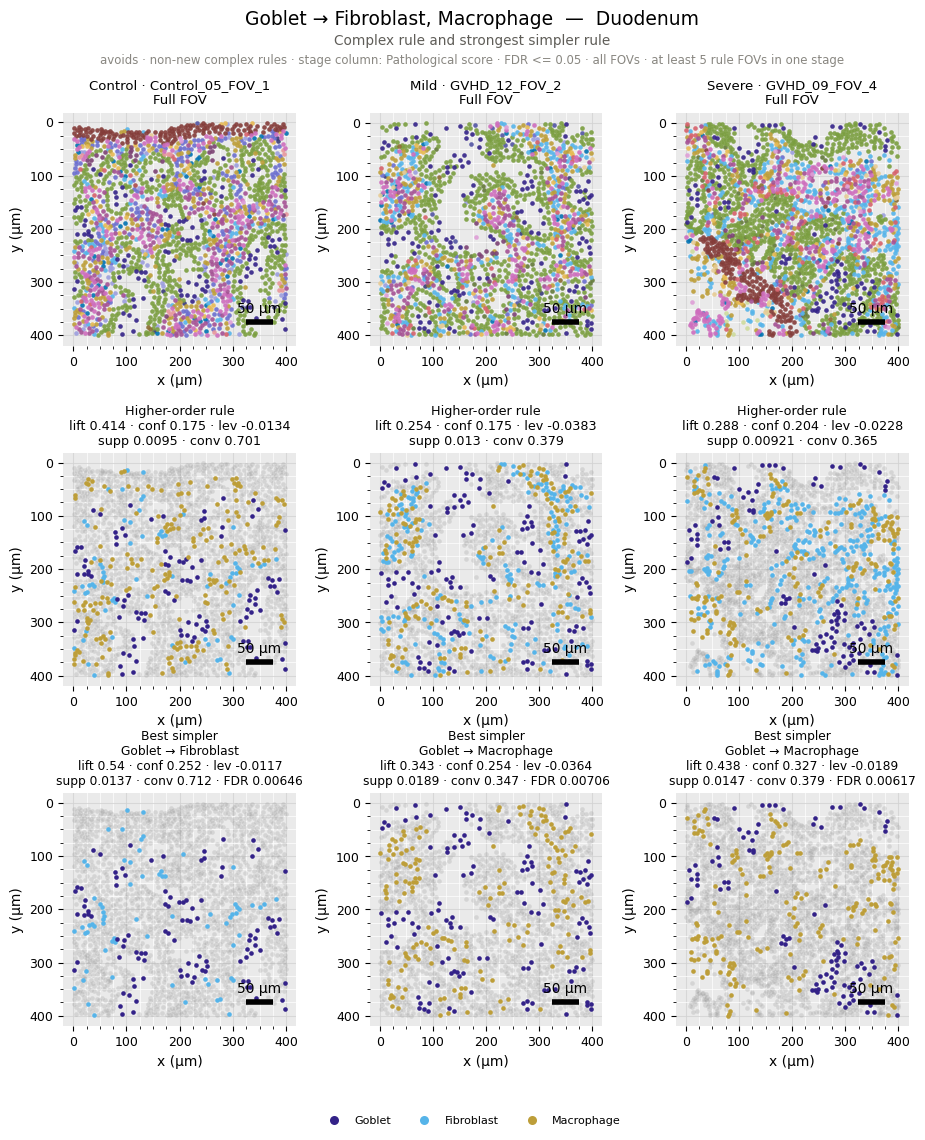

In [7]:
show_kind("avoids")
